# Perbandingan Metode Ekstraksi Fitur Gray Level Co-occurrence Matrix (GLCM), Local Binary Pattern (LBP), dan Feature Fusion pada Klasifikasi Patah Tulang Citra X-ray Menggunakan Support Vector Machine (SVM), Artificial Neural Network (ANN), dan Bayesian Neural Network (BNN) 

Kelompok 4 :
1. Nadine Putri Aulia (24031554094)
2. Umi Imro'atus Sholekhah (24031554150)
3. Cintiya Agustin Nareswari (24031554218)

Link Dataset : https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project 

In [ ]:
#0. CHECK TENSORFLOW VERSION

import tensorflow as tf
import tensorflow_probability as tfp

print("TensorFlow :", tf.__version__)
print("TF Probability :", tfp.__version__)




TensorFlow : 2.15.0
TF Probability : 0.23.0


In [2]:
# 1. IMPORT LIBRARY

import os
import cv2
import glob
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

from skimage.feature import (
    graycomatrix,
    graycoprops,
    local_binary_pattern
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import (
    compute_class_weight
)

import tensorflow as tf
import tensorflow_probability as tfp

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    Activation
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from tensorflow.keras.utils import (
    to_categorical
)

tfpl = tfp.layers

In [3]:
# 2. CREATE SAVE FOLDERS

os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_features", exist_ok=True)
os.makedirs("saved_results", exist_ok=True)
os.makedirs("saved_scalers", exist_ok=True)

In [4]:
# 3. SET SEED

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [5]:
# 4. DATASET PATH

base_path = r"C:\Users\MSI-PC\Downloads\BoneFractureYolo8"

train_images_path = os.path.join(base_path, "train", "images")
valid_images_path = os.path.join(base_path, "valid", "images")
test_images_path = os.path.join(base_path, "test", "images")

train_labels_path = os.path.join(base_path, "train", "labels")
valid_labels_path = os.path.join(base_path, "valid", "labels")
test_labels_path = os.path.join(base_path, "test", "labels")

In [6]:
# 5. DATASET INFORMATION

print("\n DATASET INFORMATION ")

print("\nTrain Images :",
      len(os.listdir(train_images_path)))

print("Validation Images :",
      len(os.listdir(valid_images_path)))

print("Test Images :",
      len(os.listdir(test_images_path)))



 DATASET INFORMATION 



Train Images : 3631
Validation Images : 348
Test Images : 169


In [7]:
# 6. LABEL INFORMATION

print("\nTrain Labels :",
      len(os.listdir(train_labels_path)))

print("Validation Labels :",
      len(os.listdir(valid_labels_path)))

print("Test Labels :",
      len(os.listdir(test_labels_path)))


Train Labels : 3631
Validation Labels : 348
Test Labels : 169


In [8]:
# 7. SAMPLE LABEL CHECK

sample_label_files = glob.glob(
    os.path.join(train_labels_path, "*.txt")
)

found = False

for file_path in sample_label_files:

    with open(file_path, "r") as f:
        content = f.read().strip()

    if content != "":

        print("\n SAMPLE LABEL ")

        print("Label File:")
        print(file_path)

        print("\nLabel Content:")
        print(content)

        found = True
        break

if not found:
    print("All label files are empty.")


 SAMPLE LABEL 
Label File:
C:\Users\MSI-PC\Downloads\BoneFractureYolo8\train\labels\distal-humeral-fractures-2-_JPEG.rf.39ba3f53047ecb4064613850a1c76fc1.txt

Label Content:
0 0.35585933923721313 0.3968750014901161 0.4525467435362568 0.3829741733292004 0.4556711770844495 0.47362547689055823 0.3681857266505504 0.48925501404327343


In [9]:
# 8. CLASS DISTRIBUTION

def collect_class_ids(labels_dir):

    counter = Counter()

    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))

    for file_path in label_files:

        with open(file_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) > 0:

                    class_id = int(float(parts[0]))
                    counter[class_id] += 1

    return counter


print("\nCLASS DISTRIBUTION")

print("Train:", collect_class_ids(train_labels_path))
print("Validation:", collect_class_ids(valid_labels_path))
print("Test:", collect_class_ids(test_labels_path))


CLASS DISTRIBUTION
Train: Counter({1: 531, 5: 360, 0: 339, 2: 316, 4: 311, 6: 228, 3: 3})
Validation: Counter({1: 48, 2: 43, 4: 36, 0: 29, 6: 28, 5: 20})
Test: Counter({1: 27, 0: 17, 5: 17, 4: 15, 2: 14, 6: 6})


In [10]:

# 9. CLASS NAME

class_names = {
    0: "Elbow Positive",
    1: "Finger Positive",
    2: "Forearm Fracture",
    4: "Humerus Fracture",
    5: "Shoulder Fracture",
    6: "Wrist Positive"
}

In [11]:
# 10. FUNCTION GET LABEL

def get_label_id(label_path):

    with open(label_path, "r") as f:
        content = f.read().strip()

    if content == "":
        return None

    first_line = content.splitlines()[0]
    class_id = int(float(first_line.split()[0]))

    return class_id

In [12]:
# 11. BUILD DATAFRAME

def build_dataframe(
    images_path,
    labels_path,
    split_name
):

    data = []

    image_files = (
        glob.glob(os.path.join(images_path, "*.jpg"))
        + glob.glob(os.path.join(images_path, "*.jpeg"))
        + glob.glob(os.path.join(images_path, "*.png"))
    )

    total_images = len(image_files)

    empty_labels = 0
    missing_labels = 0
    removed_class_3 = 0
    usable_images = 0

    print(f"\n{split_name.upper()} CLEANING")

    for img_path in image_files:

        base_name = os.path.splitext(
            os.path.basename(img_path)
        )[0]

        label_path = os.path.join(
            labels_path,
            base_name + ".txt"
        )

        # Missing label
        if not os.path.exists(label_path):
            missing_labels += 1
            continue

        # Empty label
        label_id = get_label_id(label_path)

        if label_id is None:
            empty_labels += 1
            continue

        # Remove class 3
        if label_id == 3:
            removed_class_3 += 1
            continue

        usable_images += 1
        data.append([img_path, label_id, split_name])

    print("Total Images :", total_images)
    print("Missing Labels Removed :", missing_labels)
    print("Empty Labels Removed :", empty_labels)
    print("Class 3 Removed :", removed_class_3)
    print("Final Usable Images :", usable_images)

    return pd.DataFrame(
        data,
        columns=["image_path", "label", "split"]
    )

In [13]:
# 12. CREATE DATAFRAME

train_df = build_dataframe(train_images_path, train_labels_path, "train")
valid_df = build_dataframe(valid_images_path, valid_labels_path, "validation")
test_df = build_dataframe(test_images_path, test_labels_path, "test")

df_all = pd.concat([train_df, valid_df, test_df], ignore_index=True)
df_all["class_name"] = df_all["label"].map(class_names)


TRAIN CLEANING
Total Images : 3631
Missing Labels Removed : 0
Empty Labels Removed : 1827
Class 3 Removed : 0
Final Usable Images : 1804

VALIDATION CLEANING
Total Images : 348
Missing Labels Removed : 0
Empty Labels Removed : 175
Class 3 Removed : 0
Final Usable Images : 173

TEST CLEANING
Total Images : 169
Missing Labels Removed : 0
Empty Labels Removed : 86
Class 3 Removed : 0
Final Usable Images : 83


In [14]:
# 13. REMOVE DUPLICATES

before_duplicates = len(df_all)

df_all = df_all.drop_duplicates(
    subset=["image_path"]
)

after_duplicates = len(df_all)

print("\n DUPLICATE REMOVAL ")

print("Before :", before_duplicates)

print("After :", after_duplicates)

print("Removed :",
      before_duplicates - after_duplicates)


 DUPLICATE REMOVAL 
Before : 2060
After : 2060
Removed : 0


In [15]:
# 14. FINAL DATASET INFO

print("\nFINAL DATASET")
print(df_all.head())

print("\nTotal Final Dataset:", len(df_all))

print("\nSplit Distribution:")
print(df_all["split"].value_counts())

print("\nLabel Distribution:")
print(df_all["label"].value_counts().sort_index())


FINAL DATASET
                                          image_path  label  split  \
0  C:\Users\MSI-PC\Downloads\BoneFractureYolo8\tr...      0  train   
1  C:\Users\MSI-PC\Downloads\BoneFractureYolo8\tr...      0  train   
2  C:\Users\MSI-PC\Downloads\BoneFractureYolo8\tr...      0  train   
3  C:\Users\MSI-PC\Downloads\BoneFractureYolo8\tr...      0  train   
4  C:\Users\MSI-PC\Downloads\BoneFractureYolo8\tr...      0  train   

       class_name  
0  Elbow Positive  
1  Elbow Positive  
2  Elbow Positive  
3  Elbow Positive  
4  Elbow Positive  

Total Final Dataset: 2060

Split Distribution:
split
train         1804
validation     173
test            83
Name: count, dtype: int64

Label Distribution:
label
0    347
1    496
2    333
4    344
5    349
6    191
Name: count, dtype: int64


In [16]:
# 15. PREPROCESSING FUNCTION

def preprocess_image(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize
    resized = cv2.resize(img, (224, 224))

    # Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    # Median Filter
    median = cv2.medianBlur(enhanced, 3)

    # Gaussian Blur
    final_img = cv2.GaussianBlur(
        median,
        (3, 3),
        0
    )

    return final_img

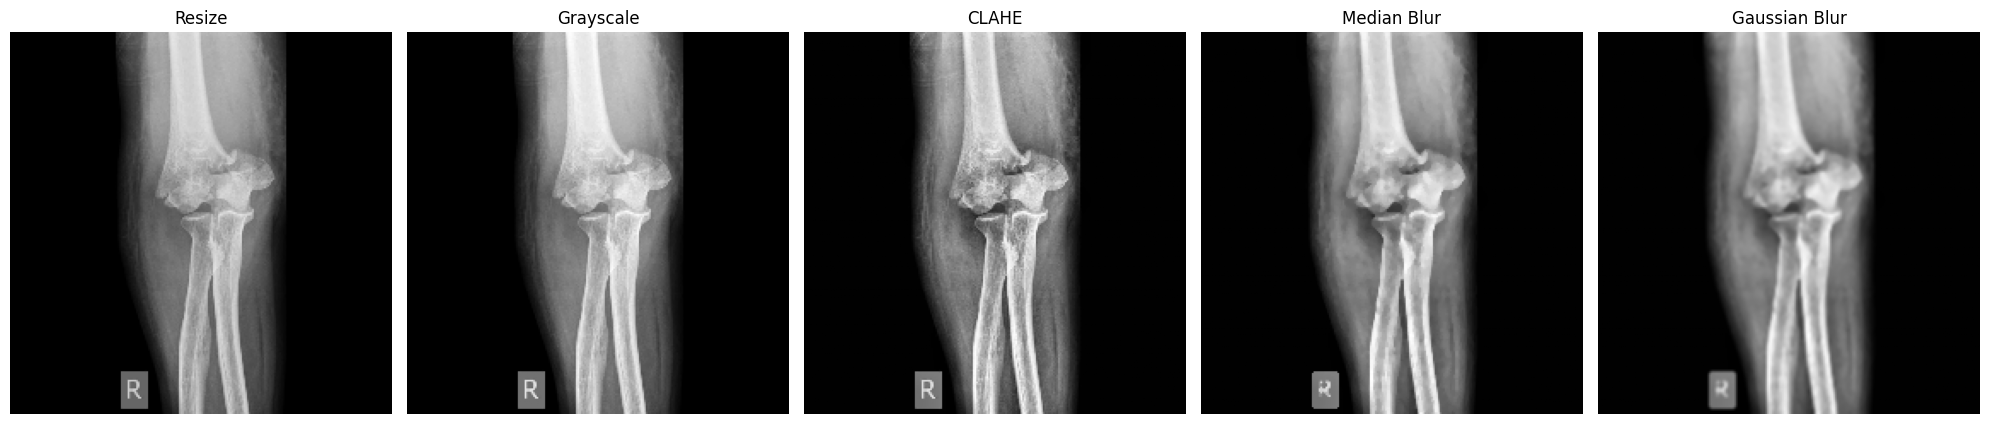

In [17]:
# 16. PREPROCESSING VISUALIZATION

sample_image = df_all.iloc[0]["image_path"]

# Original Image
original = cv2.imread(sample_image)

# Resize
resized = cv2.resize(original, (224, 224))

# Grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced = clahe.apply(gray)

# Median Blur
median = cv2.medianBlur(enhanced, 3)

# Gaussian Blur
gaussian = cv2.GaussianBlur(median, (3, 3), 0)

# SHOW PREPROCESSING RESULT

fig, ax = plt.subplots(1, 5, figsize=(20, 5))

ax[0].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
ax[0].set_title("Resize")

ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Grayscale")

ax[2].imshow(enhanced, cmap="gray")
ax[2].set_title("CLAHE")

ax[3].imshow(median, cmap="gray")
ax[3].set_title("Median Blur")

ax[4].imshow(gaussian, cmap="gray")
ax[4].set_title("Gaussian Blur")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# 17. GLCM FEATURE EXTRACTION

def extract_glcm_features(img):

    glcm = graycomatrix(

    img,

    distances=[1,2,3],

    angles=[

        0,

        np.pi/4,

        np.pi/2,

        3*np.pi/4
    ],

    levels=256,
    symmetric=True,
    normed=True
)

    features = []

    props = [
        'contrast',
        'dissimilarity',
        'homogeneity',
        'energy',
        'correlation',
        'ASM'
    ]

    for prop in props:

        values = graycoprops(glcm, prop)
        features.extend(values.flatten())

    return features

In [19]:
# 18. LBP FEATURE EXTRACTION

def extract_lbp_features(img):

    radius = 2
    n_points = 8 * radius

    lbp = local_binary_pattern(
        img,
        n_points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist

In [20]:
# 19. FEATURE EXTRACTION PROCESS

print("\nFEATURE EXTRACTION")

features = []

for idx, row in tqdm(
    df_all.iterrows(),
    total=len(df_all)
):

    img = preprocess_image(row["image_path"])

    if img is None:
        continue

    # GLCM
    glcm_feature = extract_glcm_features(img)

    # LBP
    lbp_feature = extract_lbp_features(img)

    # Fusion
    fusion_feature = np.concatenate([
        glcm_feature,
        lbp_feature
    ])

    features.append({
        "glcm": glcm_feature,
        "lbp": lbp_feature,
        "fusion": fusion_feature,
        "label": row["label"],
        "split": row["split"]
    })


FEATURE EXTRACTION


100%|██████████| 2060/2060 [11:37<00:00,  2.95it/s]


In [21]:
# 20. CREATE FEATURE DATASET

X_glcm = np.array([item["glcm"] for item in features])

X_lbp = np.array([item["lbp"] for item in features])

X_fusion = np.array([item["fusion"] for item in features])

y = np.array([item["label"] for item in features])

split = np.array([item["split"] for item in features])

print("\nGLCM Shape :", X_glcm.shape)
print("LBP Shape :", X_lbp.shape)
print("Fusion Shape :", X_fusion.shape)


GLCM Shape : (2060, 72)
LBP Shape : (2060, 18)
Fusion Shape : (2060, 90)


In [22]:

# 21. FEATURE EXTRACTION RESULT

glcm_df = pd.DataFrame(X_glcm)

print("\nGLCM Feature Sample")
print(glcm_df.head())


GLCM Feature Sample
          0           1          2          3           4           5   \
0  73.193025   80.466810  12.637212  88.645338  254.770954   80.466810   
1  60.067585   76.161194  17.497678  77.340304  212.269949   76.161194   
2  64.526225  101.417523  28.700553  81.281868  227.287243  101.417523   
3  52.449031  101.618734  29.545804  58.067325  191.122607  101.618734   
4  57.580758  108.243600  24.680954  51.391623  208.810047  108.243600   

           6          7           8           9   ...        62        63  \
0   44.190335  88.645338  473.406917  272.564788  ...  0.310603  0.303228   
1   57.452301  77.340304  406.335569  258.872210  ...  0.310794  0.303261   
2   99.449163  81.281868  430.029371  338.367665  ...  0.309200  0.302544   
3  100.394426  58.067325  379.555834  342.206172  ...  0.048896  0.044440   
4   86.430220  51.391623  411.456731  364.683954  ...  0.079021  0.072572   

         64        65        66        67        68        69        70

In [23]:
lbp_df = pd.DataFrame(X_lbp)

print("\nLBP Feature Sample")
print(lbp_df.head())


LBP Feature Sample
         0         1         2         3         4         5         6   \
0  0.006816  0.007514  0.008749  0.008550  0.009048  0.011898  0.017219   
1  0.005401  0.007753  0.007892  0.007314  0.008570  0.011878  0.016701   
2  0.006856  0.006497  0.007872  0.008191  0.007912  0.011559  0.017419   
3  0.009606  0.006876  0.008251  0.009586  0.010344  0.015625  0.022840   
4  0.010722  0.007852  0.009546  0.009447  0.011141  0.016063  0.023298   

         7         8         9         10        11        12        13  \
0  0.046636  0.144551  0.086376  0.016781  0.026427  0.009208  0.009088   
1  0.046955  0.153280  0.086137  0.017319  0.025530  0.008729  0.008630   
2  0.047832  0.161970  0.076989  0.017738  0.026666  0.008271  0.008191   
3  0.068579  0.190091  0.111986  0.031609  0.045599  0.013692  0.012715   
4  0.066486  0.181960  0.095902  0.027105  0.040956  0.012675  0.011958   

         14        15        16        17  
0  0.008709  0.006059  0.540478  0

In [24]:
fusion_df = pd.DataFrame(X_fusion)

print("\nFusion Feature Sample")
print(fusion_df.head())


Fusion Feature Sample
          0           1          2          3           4           5   \
0  73.193025   80.466810  12.637212  88.645338  254.770954   80.466810   
1  60.067585   76.161194  17.497678  77.340304  212.269949   76.161194   
2  64.526225  101.417523  28.700553  81.281868  227.287243  101.417523   
3  52.449031  101.618734  29.545804  58.067325  191.122607  101.618734   
4  57.580758  108.243600  24.680954  51.391623  208.810047  108.243600   

           6          7           8           9   ...        80        81  \
0   44.190335  88.645338  473.406917  272.564788  ...  0.144551  0.086376   
1   57.452301  77.340304  406.335569  258.872210  ...  0.153280  0.086137   
2   99.449163  81.281868  430.029371  338.367665  ...  0.161970  0.076989   
3  100.394426  58.067325  379.555834  342.206172  ...  0.190091  0.111986   
4   86.430220  51.391623  411.456731  364.683954  ...  0.181960  0.095902   

         82        83        84        85        86        87        

In [ ]:
# 22. SAVE FEATURE VECTORS

np.save("saved_features/X_glcm.npy", X_glcm)
np.save("saved_features/X_lbp.npy", X_lbp)
np.save("saved_features/X_fusion.npy", X_fusion)

np.save("saved_features/y_labels.npy", y)

print("\nFeature vectors saved successfully.")



Feature vectors saved successfully.


In [ ]:
# 23. SPLIT DATASET FUNCTION

def split_dataset(X):

    X_train = X[split == "train"]

    X_valid = X[split == "validation"]

    X_test = X[split == "test"]

    return (X_train,X_valid,X_test)


In [ ]:

# 24. SPLIT ALL FEATURE

X_train_glcm, X_valid_glcm, X_test_glcm = split_dataset(X_glcm)

X_train_lbp, X_valid_lbp, X_test_lbp = split_dataset(X_lbp)

X_train_fusion, X_valid_fusion, X_test_fusion = split_dataset(X_fusion)

y_train = y[split == "train"]

y_valid = y[split == "validation"]

y_test = y[split == "test"]

In [28]:
# 25. NORMALIZATION FUNCTION

def normalize_data(
    X_train,
    X_valid,
    X_test
):

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)
    X_test = scaler.transform(X_test)

    return X_train, X_valid, X_test, scaler

In [ ]:
# 26. NORMALIZATION PROCESS

X_train_glcm, X_valid_glcm, X_test_glcm, scaler_glcm = normalize_data(
    X_train_glcm,
    X_valid_glcm,
    X_test_glcm
)

X_train_lbp, X_valid_lbp, X_test_lbp, scaler_lbp = normalize_data(
    X_train_lbp,
    X_valid_lbp,
    X_test_lbp
)

X_train_fusion, X_valid_fusion, X_test_fusion, scaler_fusion = normalize_data(
    X_train_fusion,
    X_valid_fusion,
    X_test_fusion
)

In [ ]:
# 27. SAVE NORMALIZED FEATURES

np.save("saved_features/X_train_glcm.npy", X_train_glcm)
np.save("saved_features/X_test_glcm.npy", X_test_glcm)

np.save("saved_features/X_train_lbp.npy", X_train_lbp)
np.save("saved_features/X_test_lbp.npy", X_test_lbp)

np.save("saved_features/X_train_fusion.npy", X_train_fusion)
np.save("saved_features/X_test_fusion.npy", X_test_fusion)

print("\nNormalized features saved successfully.")


Normalized features saved successfully.


In [ ]:
# 28. SAVE SCALERS

joblib.dump(scaler_glcm, "saved_scalers/scaler_glcm.pkl")
joblib.dump(scaler_lbp, "saved_scalers/scaler_lbp.pkl")
joblib.dump(scaler_fusion, "saved_scalers/scaler_fusion.pkl")

print("\nScalers saved successfully.")


Scalers saved successfully.


In [ ]:
# 29. SAVE SCALERS

joblib.dump(scaler_glcm, "saved_scalers/scaler_glcm.pkl")
joblib.dump(scaler_lbp, "saved_scalers/scaler_lbp.pkl")
joblib.dump(scaler_fusion, "saved_scalers/scaler_fusion.pkl")

print("\nScalers saved successfully.")


Scalers saved successfully.


In [ ]:
# 30. LABEL ENCODING

encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_valid_enc = encoder.transform(y_valid)
y_test_enc = encoder.transform(y_test)

num_classes = len(np.unique(y_train_enc))

print("\nNumber of Classes :", num_classes)


Number of Classes : 6


In [ ]:
# 31. SAVE LABEL ENCODER

joblib.dump(encoder, "saved_scalers/label_encoder.pkl")

print("\nLabel encoder saved successfully.")


Label encoder saved successfully.


In [ ]:
# 32. ONE HOT ENCODING

y_train_cat = to_categorical(y_train_enc, num_classes)
y_valid_cat = to_categorical(y_valid_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

In [ ]:
# 33. CLASS WEIGHT

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(y_train_enc),

    y=y_train_enc
)

class_weights = dict(enumerate(class_weights))

print("\nClass Weight :")
print(class_weights)



Class Weight :
{0: 0.9825708061002179, 1: 0.6943802925327175, 2: 1.0624263839811543, 3: 1.0055741360089185, 4: 0.9544973544973545, 5: 1.7896825396825398}


In [ ]:
# 34. EVALUATION FUNCTION

def evaluate_model(
    y_true,
    y_pred,
    feature_name,
    model_name
):

    acc = accuracy_score(
        y_true,
        y_pred
    )

    prec = precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    print(f"\n {feature_name} + {model_name} ")

    print("Accuracy :", acc)
    print("Precision :", prec)
    print("Recall :", rec)
    print("F1-Score :", f1)

    print("\nClassification Report :\n")

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    print("\nConfusion Matrix :\n")

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    print(cm)

    # PREDICTION TABLE

    actual_labels = encoder.inverse_transform(y_true)

    pred_labels = encoder.inverse_transform(y_pred)

    prediction_df = pd.DataFrame({
        "Actual": actual_labels,
        "Predicted": pred_labels
    })

    prediction_df["Result"] = np.where(
        prediction_df["Actual"] ==
        prediction_df["Predicted"],
        "Correct",
        "Incorrect"
    )

    print("\nPREDICTION SAMPLE")

    print(prediction_df.head(20))

    # CORRECT VS INCORRECT

    correct = (
        prediction_df["Result"] == "Correct"
    ).sum()

    incorrect = (
        prediction_df["Result"] == "Incorrect"
    ).sum()

    summary_df = pd.DataFrame({
        "Category": ["Correct", "Incorrect"],
        "Count": [correct, incorrect]
    })

    print("\nPREDICTION SUMMARY")

    print(summary_df)

    # OPTIONAL SAVE CSV

    prediction_df.to_csv(
        f"saved_results/{feature_name}_{model_name}_predictions.csv",
        index=False
    )

    # CONFUSION MATRIX PLOT

    plt.figure(figsize=(6,5))

    plt.imshow(cm)

    plt.title(
        f"{feature_name} + {model_name}"
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.colorbar()

    plt.xticks(range(num_classes))
    plt.yticks(range(num_classes))

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            plt.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

    plt.tight_layout()

    plt.show()

    return [
        feature_name,
        model_name,
        acc,
        prec,
        rec,
        f1
    ]

In [ ]:
# 35. DATASET DICTIONARY

datasets = {

    "GLCM": (
        X_train_glcm,
        X_valid_glcm,
        X_test_glcm
    ),

    "LBP": (
        X_train_lbp,
        X_valid_lbp,
        X_test_lbp
    ),

    "FUSION": (
        X_train_fusion,
        X_valid_fusion,
        X_test_fusion
    )
}


 GLCM 

 TRAIN GLCM + SVM 

 GLCM + SVM 
Accuracy : 0.6265060240963856
Precision : 0.662580076825293
Recall : 0.6265060240963856
F1-Score : 0.6264930690503951

Classification Report :

              precision    recall  f1-score   support

           0       0.64      0.69      0.67        13
           1       0.72      0.59      0.65        22
           2       0.67      0.31      0.42        13
           3       0.59      0.71      0.65        14
           4       0.80      0.80      0.80        15
           5       0.31      0.67      0.42         6

    accuracy                           0.63        83
   macro avg       0.62      0.63      0.60        83
weighted avg       0.66      0.63      0.63        83


Confusion Matrix :

[[ 9  0  0  2  0  2]
 [ 0 13  0  2  0  7]
 [ 3  3  4  1  2  0]
 [ 2  0  1 10  1  0]
 [ 0  0  1  2 12  0]
 [ 0  2  0  0  0  4]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          0    Correct
1        5          2  Incorrect
2    

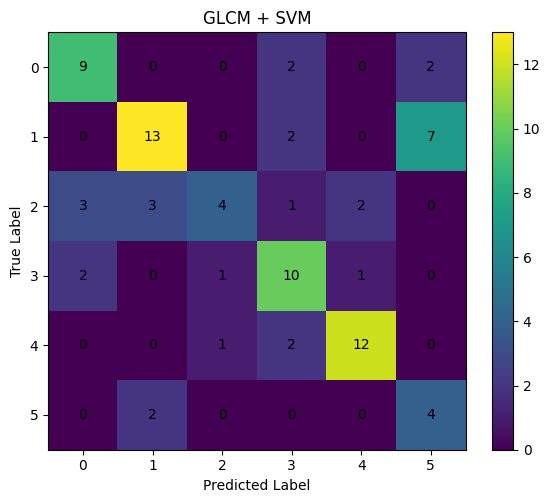


 TRAIN GLCM + ANN 



3/3 [==============================] - 1s 8ms/step

 GLCM + ANN 
Accuracy : 0.6506024096385542
Precision : 0.7070340184266478
Recall : 0.6506024096385542
F1-Score : 0.6426817410875485

Classification Report :

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        13
           1       0.81      0.59      0.68        22
           2       0.75      0.23      0.35        13
           3       0.65      0.79      0.71        14
           4       0.67      0.80      0.73        15
           5       0.33      0.83      0.48         6

    accuracy                           0.65        83
   macro avg       0.66      0.67      0.62        83
weighted avg       0.71      0.65      0.64        83


Confusion Matrix :

[[10  0  0  2  0  1]
 [ 0 13  0  0  1  8]
 [ 3  2  3  2  2  1]
 [ 0  0  0 11  3  0]
 [ 0  0  1  2 12  0]
 [ 0  1  0  0  0  5]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          4  I

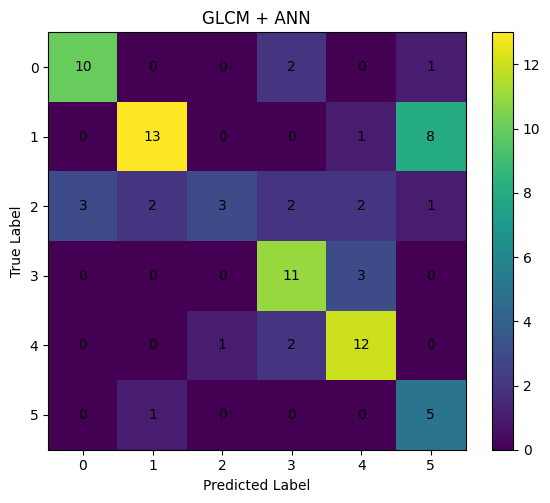


 TRAIN GLCM + BNN 


c:\Users\MSI-PC\Downloads\BoneFractureYolo8\bnn_env\lib\site-packages\tensorflow_probability\python\layers\util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
c:\Users\MSI-PC\Downloads\BoneFractureYolo8\bnn_env\lib\site-packages\tensorflow_probability\python\layers\util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


3/3 [==============================] - 1s 40ms/step

 GLCM + BNN 
Accuracy : 0.21686746987951808
Precision : 0.25254923437063764
Recall : 0.21686746987951808
F1-Score : 0.22517753435685123

Classification Report :

              precision    recall  f1-score   support

           0       0.15      0.23      0.18        13
           1       0.42      0.23      0.29        22
           2       0.36      0.31      0.33        13
           3       0.18      0.21      0.19        14
           4       0.18      0.20      0.19        15
           5       0.00      0.00      0.00         6

    accuracy                           0.22        83
   macro avg       0.21      0.20      0.20        83
weighted avg       0.25      0.22      0.23        83


Confusion Matrix :

[[3 1 1 2 4 2]
 [7 5 2 4 3 1]
 [1 0 4 3 4 1]
 [5 2 3 3 1 0]
 [2 3 1 4 3 2]
 [2 1 0 1 2 0]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          1  Incorrect
1        5          5    Correct
2        4  

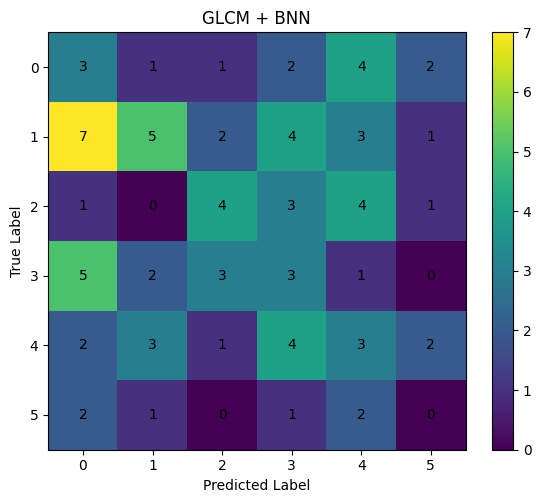


 FINAL COMPARISON 
  Feature Model  Accuracy  Precision    Recall  F1-Score
0    GLCM   SVM  0.626506   0.662580  0.626506  0.626493
1    GLCM   ANN  0.650602   0.707034  0.650602  0.642682
2    GLCM   BNN  0.216867   0.252549  0.216867  0.225178


In [ ]:
# 36. GLCM TRAIN AND EVALUATION

results=[]

feature_name="GLCM"

X_train=X_train_glcm
X_valid=X_valid_glcm
X_test=X_test_glcm

print(f"\n {feature_name} ")


# SVM MODEL

print(f"\n TRAIN {feature_name} + SVM ")

svm_model=SVC(

    kernel='rbf',

    C=10,

    gamma='scale',

    class_weight='balanced',

    probability=True
)

svm_model.fit(
    X_train,
    y_train_enc
)

y_pred_svm=svm_model.predict(
    X_test
)

svm_result=evaluate_model(

    y_test_enc,

    y_pred_svm,

    feature_name,

    "SVM"
)

results.append(
    svm_result
)

# ANN MODEL

print(f"\n TRAIN {feature_name} + ANN ")

ann_model=Sequential([

    Input(
        shape=(X_train.shape[1],)
    ),

    Dense(
        128,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

ann_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

early_ann=EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

history_ann=ann_model.fit(

    X_train,

    y_train_cat,

    validation_data=(

        X_valid,
        y_valid_cat
    ),

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_ann],

    verbose=0
)

y_pred_ann_prob=ann_model.predict(
    X_test
)

y_pred_ann=np.argmax(
    y_pred_ann_prob,
    axis=1
)

ann_result=evaluate_model(

    y_test_enc,

    y_pred_ann,

    feature_name,

    "ANN"
)

results.append(
    ann_result
)

# BNN MODEL

print(f"\n TRAIN {feature_name} + BNN ")

bnn_model=Sequential([

    Input(
        shape=(X_train.shape[1],)
    ),

    tfpl.DenseFlipout(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    tfpl.DenseFlipout(
        32,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    tfpl.DenseFlipout(
        num_classes
    ),

    tf.keras.layers.Activation(
        'softmax'
    )
])

bnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.0005
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

early_bnn=EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

history_bnn=bnn_model.fit(

    X_train,

    y_train_cat,

    validation_data=(

        X_valid,
        y_valid_cat
    ),

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_bnn],

    verbose=0
)

y_pred_bnn_prob=bnn_model.predict(
    X_test
)

y_pred_bnn=np.argmax(

    y_pred_bnn_prob,

    axis=1
)

bnn_result=evaluate_model(

    y_test_enc,

    y_pred_bnn,

    feature_name,

    "BNN"
)

results.append(
    bnn_result
)

# FINAL RESULT

comparison_df=pd.DataFrame(

    results,

    columns=[

        "Feature",

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"
    ]
)

print("\n FINAL COMPARISON ")

print(comparison_df)


 LBP 

 TRAIN LBP + SVM 



 LBP + SVM 
Accuracy : 0.5783132530120482
Precision : 0.5728609672248003
Recall : 0.5783132530120482
F1-Score : 0.5672643366542488

Classification Report :

              precision    recall  f1-score   support

           0       0.50      0.69      0.58        13
           1       0.68      0.59      0.63        22
           2       0.29      0.15      0.20        13
           3       0.69      0.64      0.67        14
           4       0.71      0.80      0.75        15
           5       0.33      0.50      0.40         6

    accuracy                           0.58        83
   macro avg       0.53      0.56      0.54        83
weighted avg       0.57      0.58      0.57        83


Confusion Matrix :

[[ 9  0  2  0  2  0]
 [ 3 13  0  1  1  4]
 [ 5  3  2  2  0  1]
 [ 0  1  2  9  2  0]
 [ 0  1  1  0 12  1]
 [ 1  1  0  1  0  3]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          5  Incorrect
1        5          2  Incorrect
2        4          4    Correct


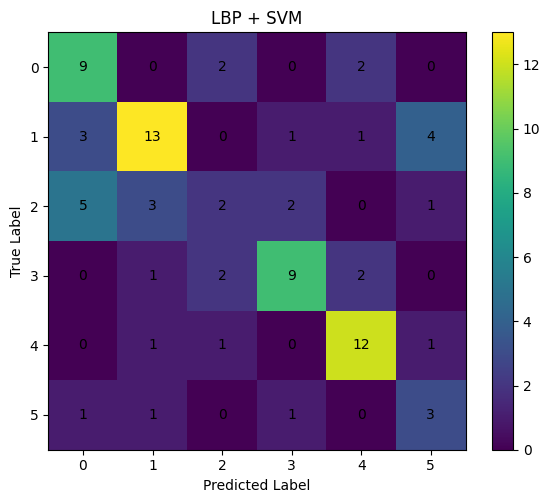


 TRAIN LBP + ANN 
3/3 [==============================] - 1s 53ms/step

 LBP + ANN 
Accuracy : 0.5180722891566265
Precision : 0.48713356098189553
Recall : 0.5180722891566265
F1-Score : 0.4987361209544059

Classification Report :

              precision    recall  f1-score   support

           0       0.41      0.54      0.47        13
           1       0.70      0.64      0.67        22
           2       0.00      0.00      0.00        13
           3       0.57      0.57      0.57        14
           4       0.71      0.80      0.75        15
           5       0.18      0.33      0.24         6

    accuracy                           0.52        83
   macro avg       0.43      0.48      0.45        83
weighted avg       0.49      0.52      0.50        83


Confusion Matrix :

[[ 7  1  1  1  2  1]
 [ 2 14  1  0  1  4]
 [ 6  2  0  2  0  3]
 [ 1  2  1  8  2  0]
 [ 0  0  0  2 12  1]
 [ 1  1  1  1  0  2]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          5  Inco

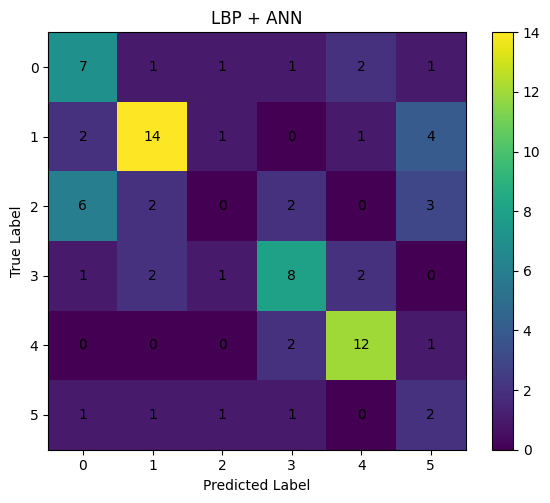


 TRAIN LBP + BNN 


c:\Users\MSI-PC\Downloads\BoneFractureYolo8\bnn_env\lib\site-packages\tensorflow_probability\python\layers\util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
c:\Users\MSI-PC\Downloads\BoneFractureYolo8\bnn_env\lib\site-packages\tensorflow_probability\python\layers\util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


3/3 [==============================] - 2s 33ms/step

 LBP + BNN 
Accuracy : 0.1566265060240964
Precision : 0.15740912367418392
Recall : 0.1566265060240964
F1-Score : 0.15413382686785176

Classification Report :

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.25      0.18      0.21        22
           2       0.28      0.38      0.32        13
           3       0.20      0.21      0.21        14
           4       0.08      0.07      0.07        15
           5       0.00      0.00      0.00         6

    accuracy                           0.16        83
   macro avg       0.13      0.14      0.14        83
weighted avg       0.16      0.16      0.15        83


Confusion Matrix :

[[0 1 5 3 3 1]
 [4 4 4 2 5 3]
 [0 3 5 3 0 2]
 [4 1 1 3 4 1]
 [1 6 1 3 1 3]
 [2 1 2 1 0 0]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          1  Incorrect
1        5          6  Incorrect
2        4     

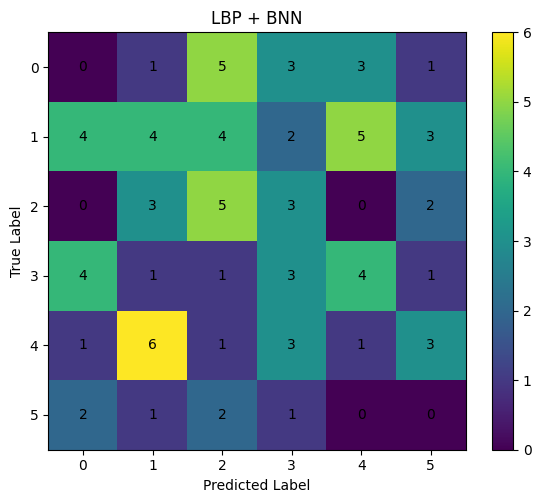


 FINAL COMPARISON 
  Feature Model  Accuracy  Precision    Recall  F1-Score
0     LBP   SVM  0.578313   0.572861  0.578313  0.567264
1     LBP   ANN  0.518072   0.487134  0.518072  0.498736
2     LBP   BNN  0.156627   0.157409  0.156627  0.154134


In [ ]:
# 37. LBP TRAIN AND EVALUATION

lbp_results=[]

feature_name="LBP"

X_train=X_train_lbp
X_valid=X_valid_lbp
X_test=X_test_lbp

print(f"\n {feature_name} ")

# SVM MODEL

print(f"\n TRAIN {feature_name} + SVM ")

svm_model=SVC(

    kernel='rbf',

    C=10,

    gamma='scale',

    class_weight='balanced',

    probability=True
)

svm_model.fit(
    X_train,
    y_train_enc
)

y_pred_svm=svm_model.predict(
    X_test
)

svm_result=evaluate_model(

    y_test_enc,

    y_pred_svm,

    feature_name,

    "SVM"
)

lbp_results.append(
    svm_result
)

# ANN MODEL

print(f"\n TRAIN {feature_name} + ANN ")

ann_model=Sequential([

    Input(
        shape=(X_train.shape[1],)
    ),

    Dense(
        128,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

ann_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

early_ann=EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

history_ann=ann_model.fit(

    X_train,

    y_train_cat,

    validation_data=(

        X_valid,
        y_valid_cat
    ),

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_ann],

    verbose=0
)

y_pred_ann_prob=ann_model.predict(
    X_test
)

y_pred_ann=np.argmax(
    y_pred_ann_prob,
    axis=1
)

ann_result=evaluate_model(

    y_test_enc,

    y_pred_ann,

    feature_name,

    "ANN"
)

lbp_results.append(
    ann_result
)

# BNN MODEL

print(f"\n TRAIN {feature_name} + BNN ")

bnn_model=Sequential([

    Input(
        shape=(X_train.shape[1],)
    ),

    tfpl.DenseFlipout(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    tfpl.DenseFlipout(
        32,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    tfpl.DenseFlipout(
        num_classes
    ),

    tf.keras.layers.Activation(
        'softmax'
    )
])

bnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.0005
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

early_bnn=EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

history_bnn=bnn_model.fit(

    X_train,

    y_train_cat,

    validation_data=(

        X_valid,
        y_valid_cat
    ),

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_bnn],

    verbose=0
)

y_pred_bnn_prob=bnn_model.predict(
    X_test
)

y_pred_bnn=np.argmax(

    y_pred_bnn_prob,

    axis=1
)

bnn_result=evaluate_model(

    y_test_enc,

    y_pred_bnn,

    feature_name,

    "BNN"
)

lbp_results.append(
    bnn_result
)

# FINAL RESULT

comparison_df=pd.DataFrame(

    lbp_results,

    columns=[

        "Feature",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print("\n FINAL COMPARISON ")

print(comparison_df)


 FUSION 

 TRAIN FUSION + SVM 

 FUSION + SVM 
Accuracy : 0.6987951807228916
Precision : 0.7076496462038631
Recall : 0.6987951807228916
F1-Score : 0.691769844354376

Classification Report :

              precision    recall  f1-score   support

           0       0.67      0.92      0.77        13
           1       0.78      0.64      0.70        22
           2       0.50      0.31      0.38        13
           3       0.80      0.86      0.83        14
           4       0.86      0.80      0.83        15
           5       0.40      0.67      0.50         6

    accuracy                           0.70        83
   macro avg       0.67      0.70      0.67        83
weighted avg       0.71      0.70      0.69        83


Confusion Matrix :

[[12  0  0  1  0  0]
 [ 1 14  1  0  0  6]
 [ 4  3  4  1  1  0]
 [ 1  0  0 12  1  0]
 [ 0  0  2  1 12  0]
 [ 0  1  1  0  0  4]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          0    Correct
1        5          2  Incorrect

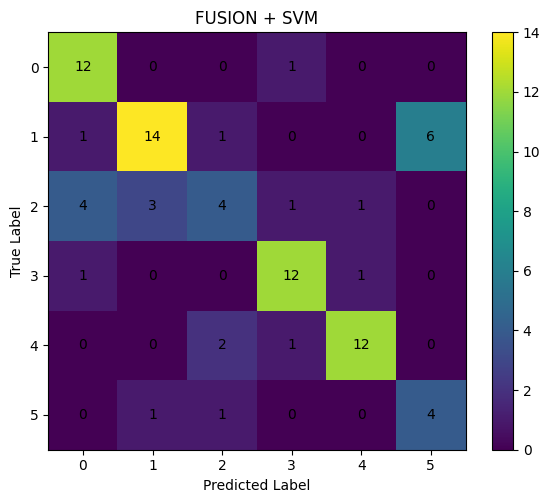


 TRAIN FUSION + ANN 
3/3 [==============================] - 0s 8ms/step

 FUSION + ANN 
Accuracy : 0.7228915662650602
Precision : 0.7579663190577436
Recall : 0.7228915662650602
F1-Score : 0.7172470177133994

Classification Report :

              precision    recall  f1-score   support

           0       0.71      0.92      0.80        13
           1       0.87      0.59      0.70        22
           2       0.71      0.38      0.50        13
           3       0.71      0.86      0.77        14
           4       0.87      0.87      0.87        15
           5       0.42      0.83      0.56         6

    accuracy                           0.72        83
   macro avg       0.71      0.74      0.70        83
weighted avg       0.76      0.72      0.72        83


Confusion Matrix :

[[12  0  0  1  0  0]
 [ 1 13  1  1  0  6]
 [ 4  1  5  1  1  1]
 [ 0  0  1 12  1  0]
 [ 0  0  0  2 13  0]
 [ 0  1  0  0  0  5]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          4  

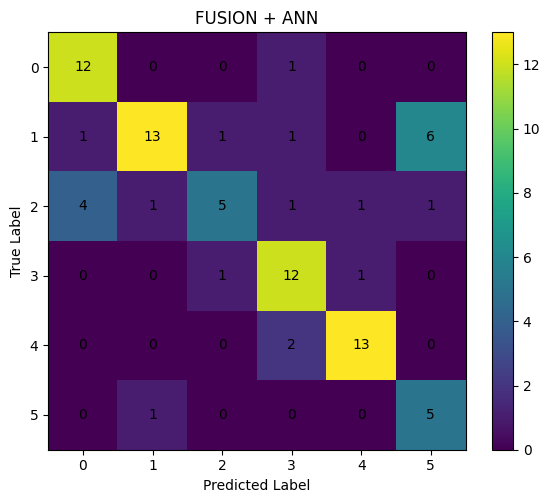


 TRAIN FUSION + BNN 


c:\Users\MSI-PC\Downloads\BoneFractureYolo8\bnn_env\lib\site-packages\tensorflow_probability\python\layers\util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
c:\Users\MSI-PC\Downloads\BoneFractureYolo8\bnn_env\lib\site-packages\tensorflow_probability\python\layers\util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


3/3 [==============================] - 2s 21ms/step

 FUSION + BNN 
Accuracy : 0.21686746987951808
Precision : 0.20702642502784246
Recall : 0.21686746987951808
F1-Score : 0.20627841697118807

Classification Report :

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.27      0.18      0.22        22
           2       0.29      0.31      0.30        13
           3       0.17      0.21      0.19        14
           4       0.29      0.33      0.31        15
           5       0.14      0.33      0.20         6

    accuracy                           0.22        83
   macro avg       0.19      0.23      0.20        83
weighted avg       0.21      0.22      0.21        83


Confusion Matrix :

[[0 2 3 3 3 2]
 [2 4 1 4 4 7]
 [0 2 4 5 1 1]
 [2 1 3 3 3 2]
 [0 5 2 3 5 0]
 [1 1 1 0 1 2]]

PREDICTION SAMPLE
    Actual  Predicted     Result
0        0          1  Incorrect
1        5          5    Correct
2        4

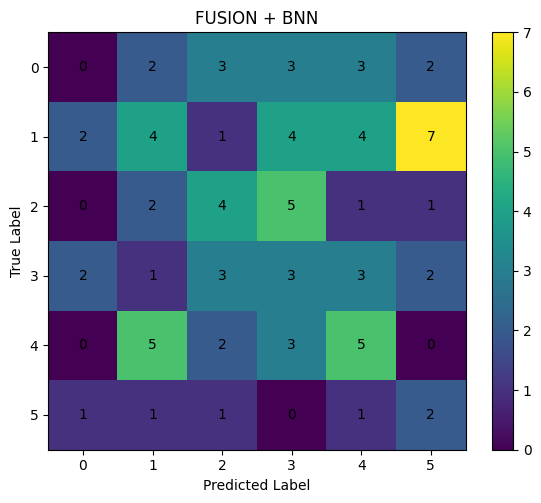


 FINAL COMPARISON 
  Feature Model  Accuracy  Precision    Recall  F1-Score
0  FUSION   SVM  0.698795   0.707650  0.698795  0.691770
1  FUSION   ANN  0.722892   0.757966  0.722892  0.717247
2  FUSION   BNN  0.216867   0.207026  0.216867  0.206278


In [ ]:
# 38. FUSION TRAIN AND EVALUATION

fusion_results=[]

feature_name="FUSION"

X_train=X_train_fusion
X_valid=X_valid_fusion
X_test=X_test_fusion

print(f"\n {feature_name} ")

# SVM MODEL

print(f"\n TRAIN {feature_name} + SVM ")

svm_model=SVC(

    kernel='rbf',

    C=10,

    gamma='scale',

    class_weight='balanced',

    probability=True
)

svm_model.fit(
    X_train,
    y_train_enc
)

y_pred_svm=svm_model.predict(
    X_test
)

svm_result=evaluate_model(

    y_test_enc,

    y_pred_svm,

    feature_name,

    "SVM"
)

fusion_results.append(
    svm_result
)

# ANN MODEL

print(f"\n TRAIN {feature_name} + ANN ")

ann_model=Sequential([

    Input(
        shape=(X_train.shape[1],)
    ),

    Dense(
        128,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

ann_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

early_ann=EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

history_ann=ann_model.fit(

    X_train,

    y_train_cat,

    validation_data=(

        X_valid,
        y_valid_cat
    ),

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_ann],

    verbose=0
)

y_pred_ann_prob=ann_model.predict(
    X_test
)

y_pred_ann=np.argmax(
    y_pred_ann_prob,
    axis=1
)

ann_result=evaluate_model(

    y_test_enc,

    y_pred_ann,

    feature_name,

    "ANN"
)

fusion_results.append(
    ann_result
)

# BNN MODEL

print(f"\n TRAIN {feature_name} + BNN ")

bnn_model=Sequential([

    Input(
        shape=(X_train.shape[1],)
    ),

    tfpl.DenseFlipout(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    tfpl.DenseFlipout(
        32,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    tfpl.DenseFlipout(
        num_classes
    ),

    tf.keras.layers.Activation(
        'softmax'
    )
])

bnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.0005
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

early_bnn=EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

history_bnn=bnn_model.fit(

    X_train,

    y_train_cat,

    validation_data=(

        X_valid,
        y_valid_cat
    ),

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_bnn],

    verbose=0
)

y_pred_bnn_prob=bnn_model.predict(
    X_test
)

y_pred_bnn=np.argmax(

    y_pred_bnn_prob,

    axis=1
)

bnn_result=evaluate_model(

    y_test_enc,

    y_pred_bnn,

    feature_name,

    "BNN"
)

fusion_results.append(
    bnn_result
)

# FINAL RESULT

comparison_df=pd.DataFrame(

    fusion_results,

    columns=[

        "Feature",

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"
    ]
)

print("\n FINAL COMPARISON ")

print(comparison_df)

In [ ]:
# 39. FINAL COMPARISON ALL MODEL

all_results = (

    results +

    lbp_results +

    fusion_results
)

comparison_df = pd.DataFrame(

    all_results,

    columns=[

        "Feature",

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"
    ]
)

print("\n FINAL COMPARISON ")

print(comparison_df)


 FINAL COMPARISON 
  Feature Model  Accuracy  Precision    Recall  F1-Score
0    GLCM   SVM  0.626506   0.662580  0.626506  0.626493
1    GLCM   ANN  0.650602   0.707034  0.650602  0.642682
2    GLCM   BNN  0.216867   0.252549  0.216867  0.225178
3     LBP   SVM  0.578313   0.572861  0.578313  0.567264
4     LBP   ANN  0.518072   0.487134  0.518072  0.498736
5     LBP   BNN  0.156627   0.157409  0.156627  0.154134
6  FUSION   SVM  0.698795   0.707650  0.698795  0.691770
7  FUSION   ANN  0.722892   0.757966  0.722892  0.717247
8  FUSION   BNN  0.216867   0.207026  0.216867  0.206278


In [ ]:
# 40. SAVE FINAL RESULT

comparison_df.to_csv(

    "saved_results/final_comparison_results.csv",

    index=False
)

print("\nFinal comparison table saved successfully.")


Final comparison table saved successfully.


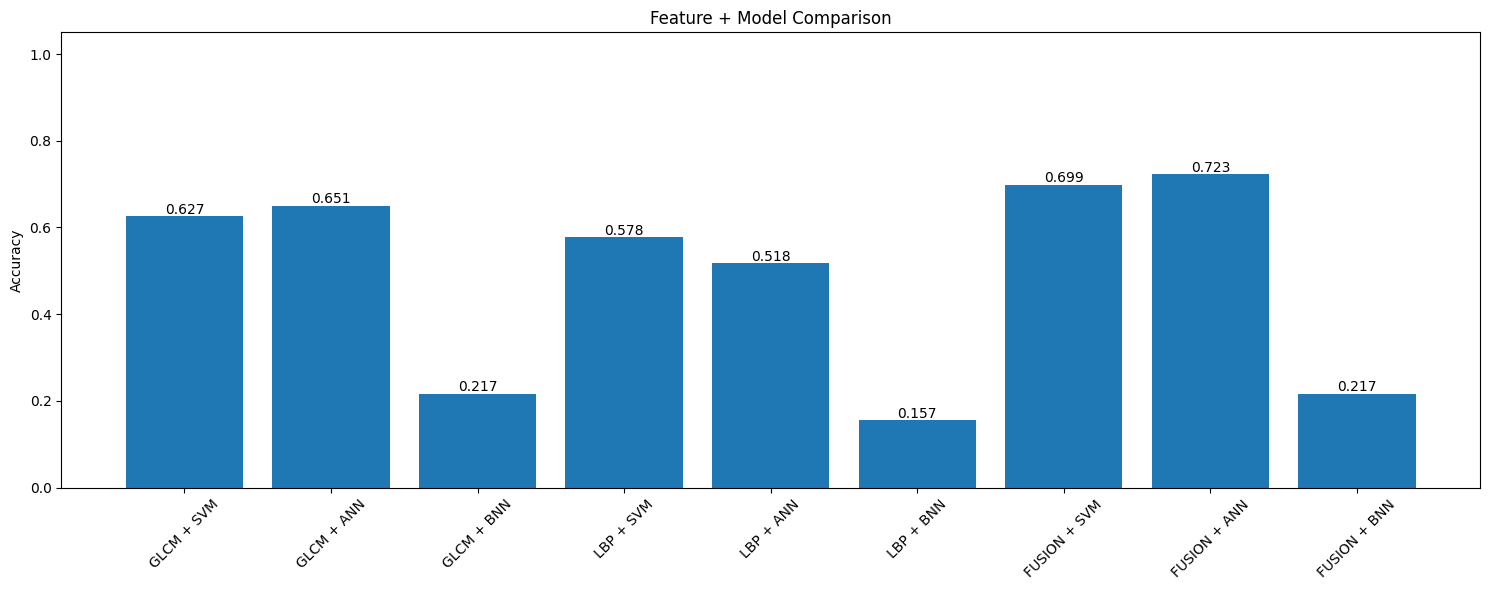

In [ ]:
# 41. VISUALIZATION

plt.figure(figsize=(15, 6))

labels = [
    comparison_df["Feature"][i] + " + " + comparison_df["Model"][i]
    for i in range(len(comparison_df))
]

scores = comparison_df["Accuracy"]

bars = plt.bar(labels, scores)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.xticks(rotation=45)

plt.ylabel("Accuracy")
plt.title("Feature + Model Comparison")

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [49]:
# 42. BEST MODEL

best_model = comparison_df.loc[comparison_df["Accuracy"].idxmax()]

print("\nBEST MODEL")
print(best_model)



BEST MODEL
Feature        FUSION
Model             ANN
Accuracy     0.722892
Precision    0.757966
Recall       0.722892
F1-Score     0.717247
Name: 7, dtype: object
